In [13]:
%matplotlib inline

In [2]:
import sys
sys.path.insert(0, "/home/tsingh65/m61-tng/notebooks")

import pygad_fit_saved_spectra as pfit
pfit.notebook_setup()

reading units definitions from "units.cfg"
reading config file "gadget.cfg"
reading config file "/home/tsingh65/pygad/pygad/config/derived.cfg"
('imported pygad', '0.10.1+148.g8e4e368.dirty')
Notebook setup complete.
pygad loaded from: /home/tsingh65/pygad/pygad/__init__.py
N pygad lines: 46


In [4]:
pfit.validate_line_map()

{'Si II 1190': True,
 'Si II 1193': True,
 'Si III 1206': True,
 'N V 1239': True,
 'Si II 1260': True,
 'O I 1302': True,
 'C II 1335': True,
 'Si IV 1403': True,
 'H I 1216': True,
 'H I 1026': True,
 'O VI 1032': True,
 'O VI 1038': True,
 'C II 1036': True,
 'N V 1243': True,
 'Si IV 1394': True}

In [5]:
pfit.print_available_pygad_lines()

H1215
H1025
H972
HeII
CII1036
CII1334
CII1335
CIII977
CIV1548
CIV1550
MgII2796
MgII2803
NI1199
NI1200
NI1201
NII1083
NV1238
NV1242
NeVIII770
NeVIII780
OI1302
OI1304
OI1306
OIV787
OVI1031
OVI1037
OVII21
OVIII19
SiII1190
SiII1193
SiII1260
SiIII1206
SiIV1393
SiIV1402
SI1295
SI1425
SI1473
SII1250
SII1253
SII1259
SIII1190
FeII2586
FeII2600
Lyman_alpha
Lyman_beta
Lyman_gamma


In [ ]:
import copy
from astropy.table import vstack

LINE_FIT_PARAMS = {
    "Si II 1190": {
        "logN_bounds": (12.3, 16.5),
        "b_bounds": (6.0, 60.0),
        "velocity_window": 800.0,
        "upper_limit_window": 50.0,
        "max_lines": 4,
        "chisq_lim": 1.3,
    },
    "Si II 1193": {
        "logN_bounds": (12.2, 16.5),
        "b_bounds": (6.0, 60.0),
        "velocity_window": 600.0,
        "upper_limit_window": 50.0,
        "max_lines": 4,
        "chisq_lim": 1.3,
    },
    "Si III 1206": {
        "logN_bounds": (11.8, 16.5),
        "b_bounds": (6.0, 80.0),
        "velocity_window": 800.0,
        "upper_limit_window": 50.0,
        "max_lines": 5,
        "chisq_lim": 1.3,
    },
    "N V 1239": {
        "logN_bounds": (12.7, 16.8),
        "b_bounds": (6.0, 100.0),
        "velocity_window": 800.0,
        "upper_limit_window": 50.0,
        "max_lines": 5,
        "chisq_lim": 1.3,
    },
    "Si II 1260": {
        "logN_bounds": (11.9, 16.5),
        "b_bounds": (6.0, 60.0),
        "velocity_window": 800.0,
        "upper_limit_window": 50.0,
        "max_lines": 4,
        "chisq_lim": 1.3,
    },
    "O I 1302": {
        "logN_bounds": (13.1, 17.0),
        "b_bounds": (6.0, 50.0),
        "velocity_window": 800.0,
        "upper_limit_window": 50.0,
        "max_lines": 3,
        "chisq_lim": 1.3,
    },
    "C II 1335": {
        "logN_bounds": (12.7, 17.0),
        "b_bounds": (6.0, 70.0),
        "velocity_window": 800.0,
        "upper_limit_window": 50.0,
        "max_lines": 4,
        "chisq_lim": 1.3,
    },
    "Si IV 1403": {
        "logN_bounds": (12.4, 16.8),
        "b_bounds": (6.0, 90.0),
        "velocity_window": 800.0,
        "upper_limit_window": 50.0,
        "max_lines": 5,
        "chisq_lim": 1.3,
    },
    "H I 1216": {
        "logN_bounds": (12.3, 19.5),
        "b_bounds": (8.0, 150.0),
        "velocity_window": 1200.0,
        "upper_limit_window": 50.0,
        "max_lines": 6,
        "chisq_lim": 1.3,
    },
}

In [19]:
base_cfg = pfit.FitConfig(
    sid=488530,
    snap=99,
    run_label="L4Rvir",
    base_dir="/scratch/tsingh65/m61-tng/outputs",
    z=0.0,
    snr=10.0,

    # These are fallback values only.
    # The line-specific values in LINE_FIT_PARAMS override them below.
    velocity_window=800,
    upper_limit_window=50,
    logN_bounds=(12, 18),
    b_bounds=(6, 100),
    chisq_lim=1.3,
    max_lines=6,

    # Shared analysis settings.
    bin_before_noise=True,
    bin_npix=3,
    N_sigma=3,
    min_region_width=3,

    line_labels=list(LINE_FIT_PARAMS.keys()),

    make_plots=True,
    verbose=True,
)

spectrum_file = "/scratch/tsingh65/m61-tng/outputs/sid488530/rays_and_spectra_sid488530_snap99_L4Rvir/spectra_h5/L4Rvir_sid488530_J122138+043026_flip_alpha5_spectrum.h5"

In [ ]:
import copy
all_tables = []
all_diagnostics = []

for line_label, params in LINE_FIT_PARAMS.items():
    cfg_line = copy.deepcopy(base_cfg)

    cfg_line.line_labels = [line_label]
    cfg_line.logN_bounds = params["logN_bounds"]
    cfg_line.b_bounds = params["b_bounds"]
    cfg_line.velocity_window = params["velocity_window"]
    cfg_line.upper_limit_window = params["upper_limit_window"]
    cfg_line.max_lines = params["max_lines"]
    cfg_line.chisq_lim = params["chisq_lim"]

    print("=" * 100)
    print(f"Fitting {line_label}")
    print(f"  logN_bounds        = {cfg_line.logN_bounds}")
    print(f"  b_bounds           = {cfg_line.b_bounds}")
    print(f"  velocity_window    = ±{cfg_line.velocity_window} km/s")
    print(f"  upper_limit_window = ±{cfg_line.upper_limit_window} km/s")
    print(f"  max_lines          = {cfg_line.max_lines}")
    print(f"  chisq_lim          = {cfg_line.chisq_lim}")
    print("=" * 100)

    table_line, diagnostics_line = pfit.fit_all_lines_in_file(
        spectrum_file=spectrum_file,
        cfg=cfg_line,
        make_plots=cfg_line.make_plots,
    )

    all_tables.append(table_line)
    all_diagnostics.extend(diagnostics_line)


table

Fitting Si II 1190
  logN_bounds        = (12.3, 16.5)
  b_bounds           = (6.0, 60.0)
  velocity_window    = ±600.0 km/s
  upper_limit_window = ±50.0 km/s
  max_lines          = 4
  chisq_lim          = 1.3

Loaded spectrum
--------------------------------------------------------------------------------
file       : /scratch/tsingh65/m61-tng/outputs/sid488530/rays_and_spectra_sid488530_snap99_L4Rvir/spectra_h5/L4Rvir_sid488530_J122138+043026_flip_alpha5_spectrum.h5
wave_key   : spectrum/lsf/lambda_A
flux_key   : spectrum/lsf/flux
tau_key    : spectrum/lsf/tau
N pixels   : 30001
wave range : 1150.0000 - 1450.0000
flux range : 0.0000 - 1.0000
LSF status : assumed already included in saved spectrum
Binning    : True, bin_npix=3
Noise      : SNR=10, added after binning
--------------------------------------------------------------------------------
Fitting Si II 1190   -> SiII1190  
Found 2 detection regions
Found 2 detection regions
Region 0: 1 lines gives chisq=1.81141 (1.3) after 23

NameError: name 'vstack' is not defined

In [22]:
from astropy.table import vstack    

table = vstack(all_tables)
diagnostics = all_diagnostics

In [23]:
pfit.write_fit_outputs(cfg, table, tag="one_file_flip_alpha5")

Wrote fixed-width table: /scratch/tsingh65/m61-tng/outputs/sid488530/rays_and_spectra_sid488530_snap99_L4Rvir/test_pygad_fits_snr10/fit_results_sid488530_one_file_flip_alpha5.txt
Wrote CSV table        : /scratch/tsingh65/m61-tng/outputs/sid488530/rays_and_spectra_sid488530_snap99_L4Rvir/test_pygad_fits_snr10/fit_results_sid488530_one_file_flip_alpha5.csv


('/scratch/tsingh65/m61-tng/outputs/sid488530/rays_and_spectra_sid488530_snap99_L4Rvir/test_pygad_fits_snr10/fit_results_sid488530_one_file_flip_alpha5.txt',
 '/scratch/tsingh65/m61-tng/outputs/sid488530/rays_and_spectra_sid488530_snap99_L4Rvir/test_pygad_fits_snr10/fit_results_sid488530_one_file_flip_alpha5.csv')

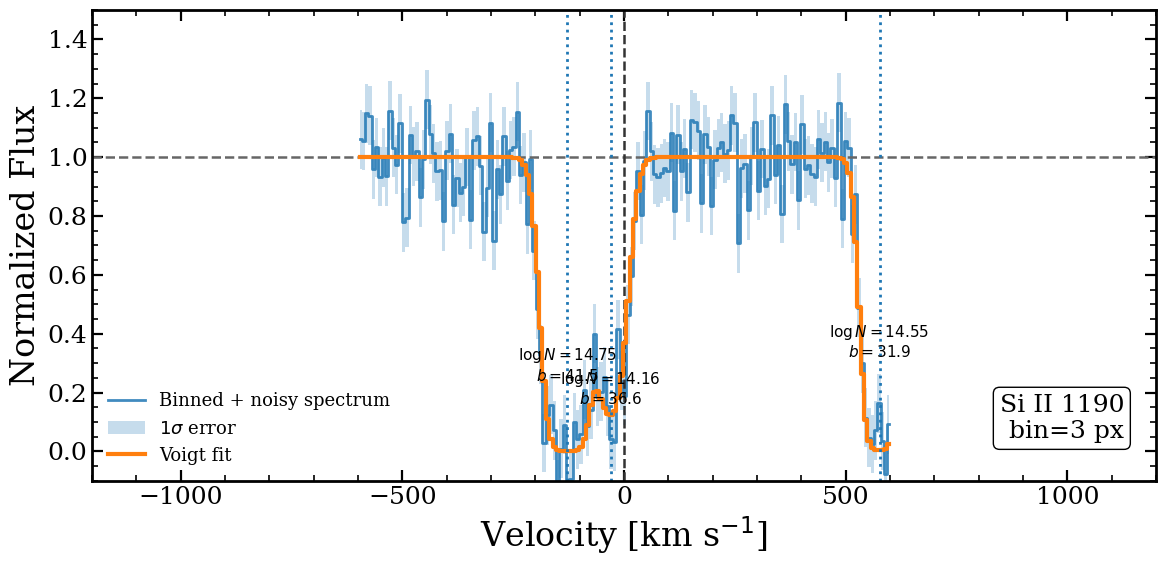

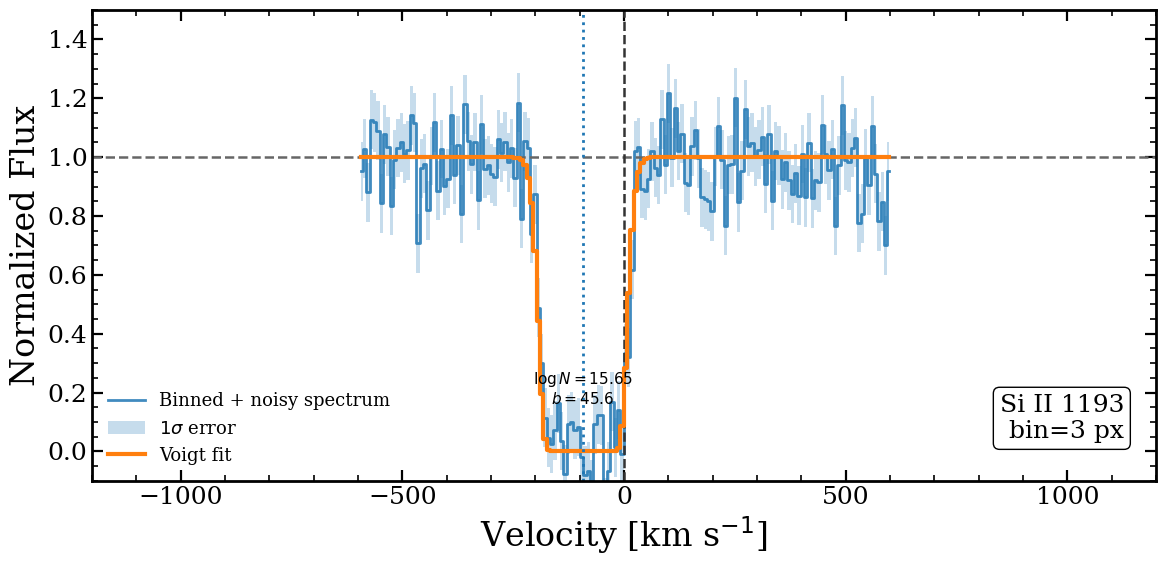

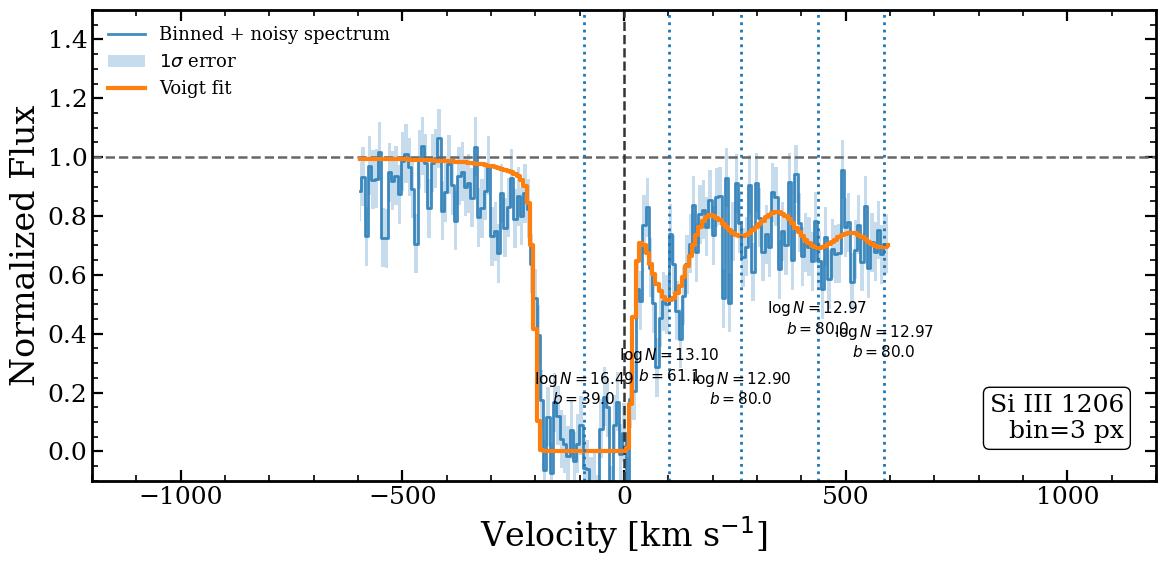

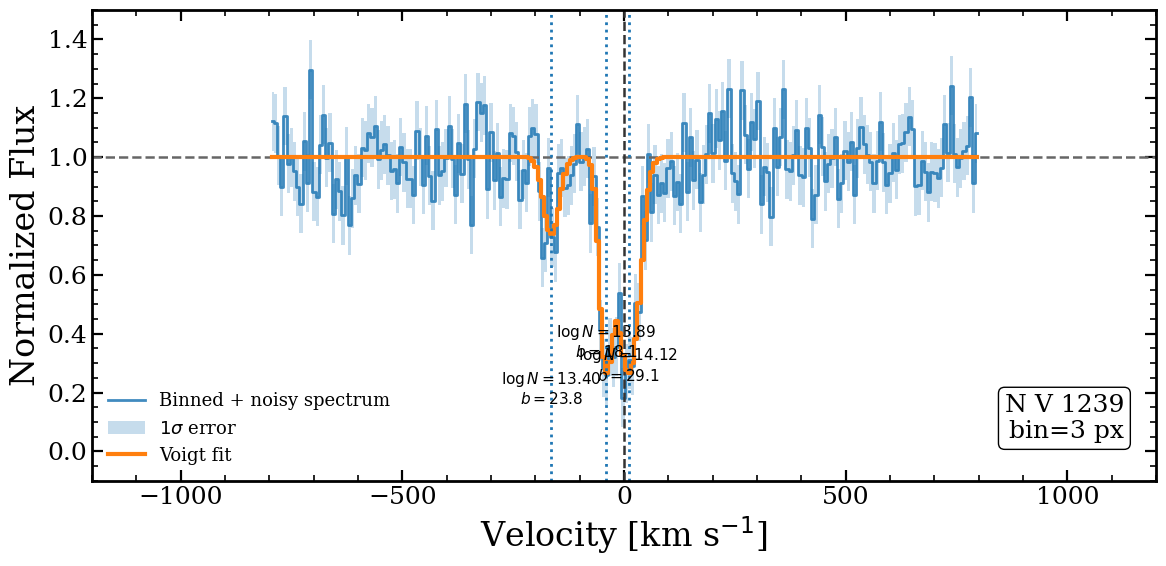

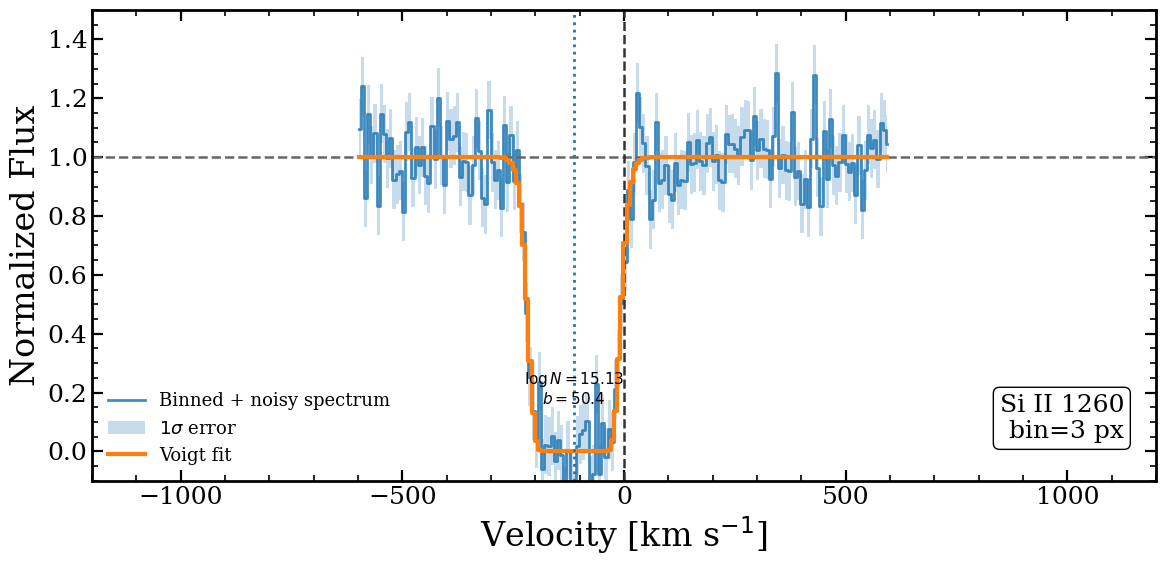

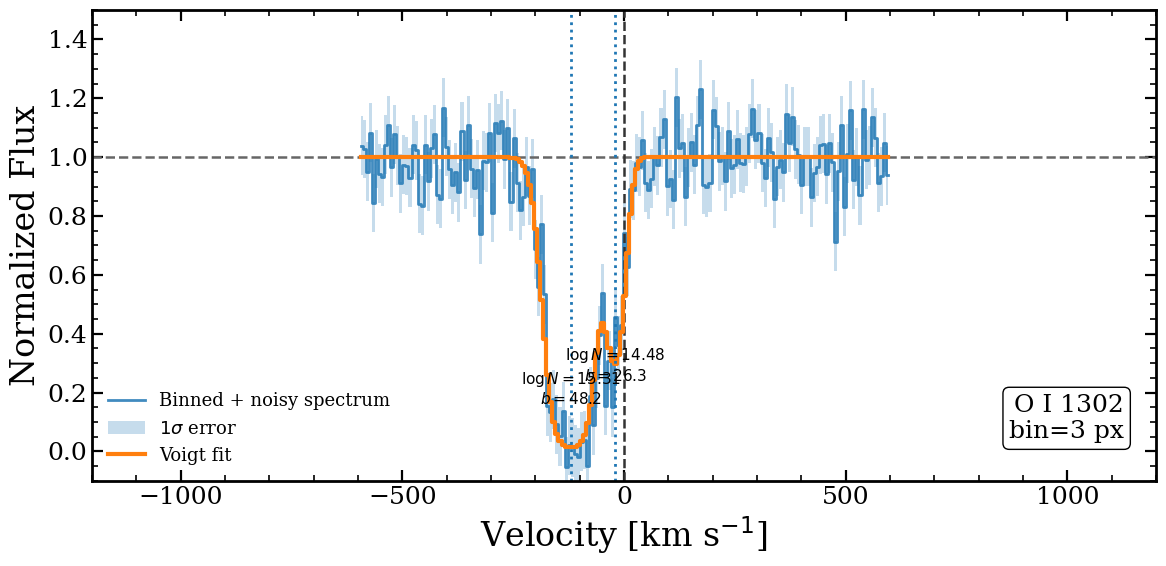

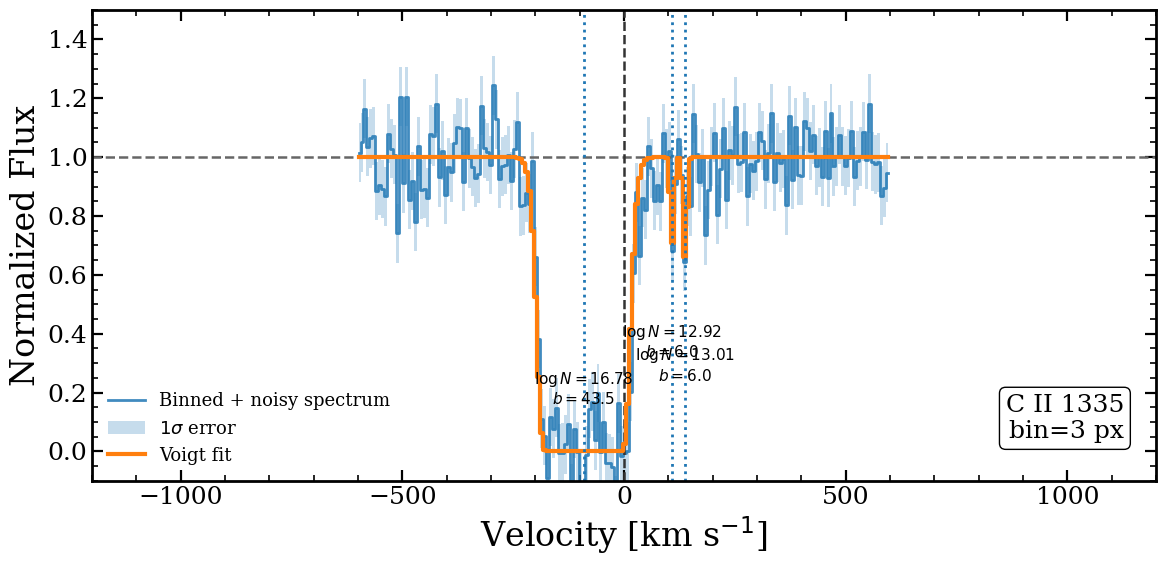

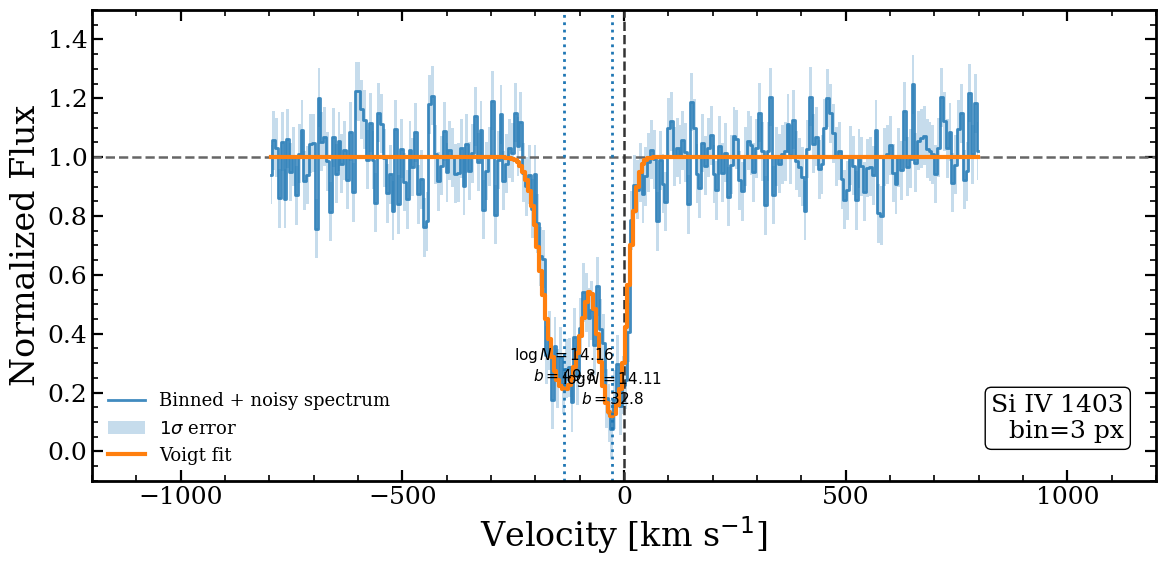

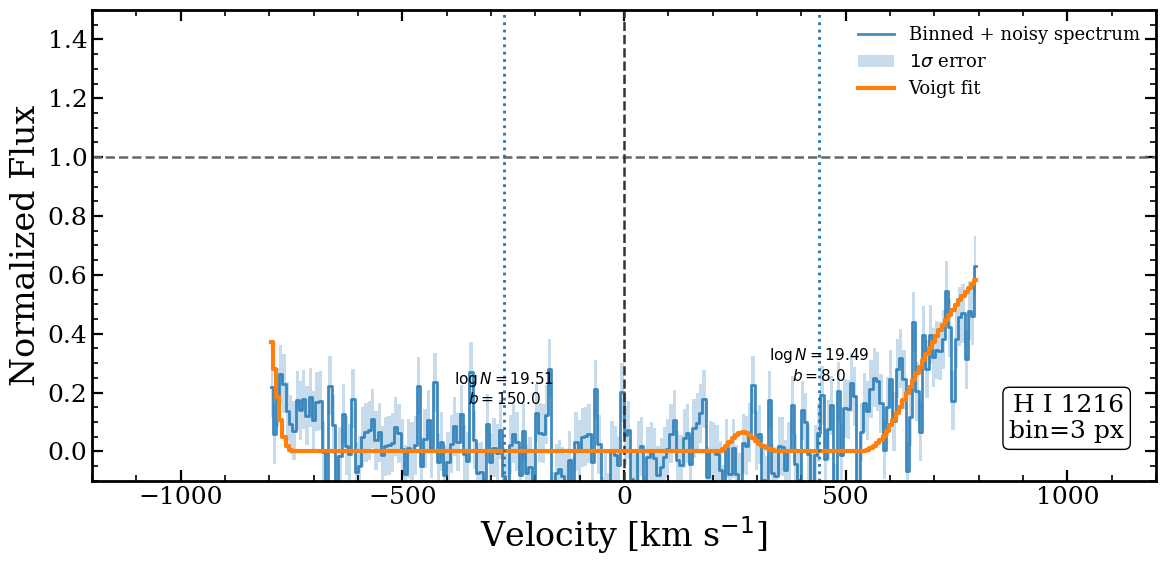

In [25]:
for d in diagnostics:
    pfit.show_diagnostic_inline(d, cfg)

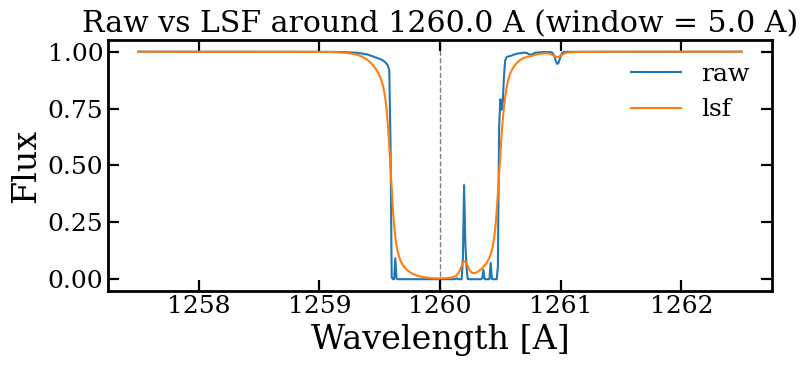

Adjacent wavelength differences (global):
  raw: n=30000, median=0.010000000000, min=0.010000000000, max=0.010000000000
  lsf: n=30000, median=0.010000000000, min=0.010000000000, max=0.010000000000

First 10 adjacent wavelength diffs:
  raw: [0.01 0.01 0.01 0.01 0.01 0.01 0.01 0.01 0.01 0.01]
  lsf: [0.01 0.01 0.01 0.01 0.01 0.01 0.01 0.01 0.01 0.01]

Adjacent flux differences in the 5 A window:
  raw: n=500, median=0.000000e+00, min=-6.038545e-01, max=6.092789e-01
  raw first 10: [0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
  lsf: n=500, median=0.000000e+00, min=-9.532567e-02, max=8.661554e-02
  lsf first 10: [0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]


In [26]:
import h5py
import numpy as np
import matplotlib.pyplot as plt

# Example saved spectrum file
spectrum_file = "/scratch/tsingh65/m61-tng/outputs/sid488530/rays_and_spectra_sid488530_snap99_L4Rvir/spectra_h5/L4Rvir_sid488530_J122138+043026_flip_alpha5_spectrum.h5"

# 5 A window around Si II 1260 line center
line_center = 1260.0
half_window_A = 2.5

with h5py.File(spectrum_file, "r") as h5:
    lam_raw = h5["spectrum"]["raw"]["lambda_A"][()]
    flux_raw = h5["spectrum"]["raw"]["flux"][()]

    lam_lsf = h5["spectrum"]["lsf"]["lambda_A"][()]
    flux_lsf = h5["spectrum"]["lsf"]["flux"][()]

# Plot window mask
mask_raw = (lam_raw >= line_center - half_window_A) & (lam_raw <= line_center + half_window_A)
mask_lsf = (lam_lsf >= line_center - half_window_A) & (lam_lsf <= line_center + half_window_A)

plt.figure(figsize=(8, 4))
plt.plot(lam_raw[mask_raw], flux_raw[mask_raw], label="raw", lw=1.5)
plt.plot(lam_lsf[mask_lsf], flux_lsf[mask_lsf], label="lsf", lw=1.5)
plt.axvline(line_center, ls="--", lw=1, color="k", alpha=0.5)
plt.xlabel("Wavelength [A]")
plt.ylabel("Flux")
plt.title(f"Raw vs LSF around {line_center:.1f} A (window = {2*half_window_A:.1f} A)")
plt.legend()
plt.tight_layout()
plt.show()

# Adjacent-element differences
dlam_raw = np.diff(lam_raw)
dlam_lsf = np.diff(lam_lsf)
dflux_raw = np.diff(flux_raw)
dflux_lsf = np.diff(flux_lsf)

print("Adjacent wavelength differences (global):")
print(f"  raw: n={dlam_raw.size}, median={np.median(dlam_raw):.12f}, min={dlam_raw.min():.12f}, max={dlam_raw.max():.12f}")
print(f"  lsf: n={dlam_lsf.size}, median={np.median(dlam_lsf):.12f}, min={dlam_lsf.min():.12f}, max={dlam_lsf.max():.12f}")

print("\nFirst 10 adjacent wavelength diffs:")
print("  raw:", dlam_raw[:10])
print("  lsf:", dlam_lsf[:10])

print("\nAdjacent flux differences in the 5 A window:")
idx_raw = np.where(mask_raw)[0]
idx_lsf = np.where(mask_lsf)[0]

# diff within the selected window only
if idx_raw.size > 1:
    dflux_raw_win = np.diff(flux_raw[idx_raw])
    print(f"  raw: n={dflux_raw_win.size}, median={np.median(dflux_raw_win):.6e}, min={dflux_raw_win.min():.6e}, max={dflux_raw_win.max():.6e}")
    print("  raw first 10:", dflux_raw_win[:10])
else:
    print("  raw: not enough points in window")

if idx_lsf.size > 1:
    dflux_lsf_win = np.diff(flux_lsf[idx_lsf])
    print(f"  lsf: n={dflux_lsf_win.size}, median={np.median(dflux_lsf_win):.6e}, min={dflux_lsf_win.min():.6e}, max={dflux_lsf_win.max():.6e}")
    print("  lsf first 10:", dflux_lsf_win[:10])
else:
    print("  lsf: not enough points in window")

In [8]:
import numpy as np
import pandas as pd
import h5py

C_KMS = 299792.458
snr = 10.0
LINE_MAP = {
    "Si II 1190": "SiII1190",
    "Si II 1193": "SiII1193",
    "Si III 1206": "SiIII1206",
    "N V 1239": "NV1238",
    "Si II 1260": "SiII1260",
    "O I 1302": "OI1302",
    "C II 1335": "CII1334",
    "Si IV 1403": "SiIV1402",
    "H I 1216": "H1215",
}

line_db = pd.read_csv(
    "/home/tsingh65/pygad/pygad/analysis/line_data.csv",
    comment="#",
    header=None,
    names=["key", "ion", "l", "f", "atomwt", "A_ki", "element"],
)

spectrum_file = "/scratch/tsingh65/m61-tng/outputs/sid488530/rays_and_spectra_sid488530_snap99_L4Rvir/spectra_h5/L4Rvir_sid488530_J122138+043026_flip_alpha5_spectrum.h5"

with h5py.File(spectrum_file, "r") as h5:
    wave = h5["spectrum"]["raw"]["lambda_A"][()]
    dw = float(np.median(np.diff(wave)))

rows = []
for label, ion_key in LINE_MAP.items():
    row = line_db.loc[line_db["key"] == ion_key].iloc[0]
    lam = float(str(row["l"]).split()[0])
    fosc = float(row["f"])

    window_A = 2.0 * 50.0 / C_KMS * lam
    n_pix = window_A / dw

    # Continuum-normalized flux error for SNR=10.
    sigma_flux = 1.0 / snr
    dew_mA = sigma_flux * np.sqrt(n_pix) * dw * 1.0e3
    ew_3sigma_mA = 3.0 * dew_mA

    # Draine eq. 9.15 in convenient units.
    N_lim = 1.13e20 * (ew_3sigma_mA * 1.0e-3) / (fosc * lam**2)

    rows.append({
        "Line": label,
        "PygadIon": ion_key,
        "lambda_A": lam,
        "f": fosc,
        "dw_A": dw,
        "EW_1sigma_mA": dew_mA,
        "EW_3sigma_mA": ew_3sigma_mA,
        "logN_3sigma": np.log10(N_lim),
    })

limits = pd.DataFrame(rows)
limits

,Line,PygadIon,lambda_A,f,dw_A,EW_1sigma_mA,EW_3sigma_mA,logN_3sigma
0,Si II 1190,SiII1190,1190.4160,0.29300,0.01,6.301429,18.904286,12.711374
1,Si II 1193,SiII1193,1193.2900,0.58500,0.01,6.309031,18.927092,12.409514
2,Si III 1206,SiIII1206,1206.5000,1.66900,0.01,6.343856,19.031568,11.947042
3,N V 1239,NV1238,1238.8210,0.15600,0.01,6.428267,19.284802,12.959152
4,Si II 1260,SiII1260,1260.5220,1.18000,0.01,6.484326,19.452979,12.069082
5,O I 1302,OI1302,1302.1680,0.05190,0.01,6.590573,19.771718,13.404621
6,C II 1335,CII1334,1334.5320,0.12700,0.01,6.671971,20.015913,12.999992
7,Si IV 1403,SiIV1402,1402.7700,0.25530,0.01,6.840422,20.521265,12.664259
8,H I 1216,H1215,1215.6701,0.41641,0.01,6.367919,19.103756,12.545045
